# Продвинутый анализ моделей

## Импорт

Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
from statsforecast import StatsForecast
from statsforecast.models import *

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse, smape, mase

In [3]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import kpss
import pmdarima as pm

In [4]:
# def matplotlib2GOST:
plt.rcParams.update({
    # ШРИФТ
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 11,                      # ГОСТ: 10–12 pt

    # ОСИ И ПОДПИСИ
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10,

    # РАЗМЕР ФИГУРЫ (A4, отчёты)
    # "figure.figsize": (6.5, 4.0),         # ~16.5 × 10 см
    "figure.figsize": (12, 3.0),         
    "figure.dpi": 150,
    "savefig.dpi": 300,

    # СОХРАНЕНИЕ
    "savefig.format": "pdf",
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,

    # ЛИНИИ И ОСИ
    "axes.linewidth": 1.0,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    "lines.linewidth": 1.5,
    "patch.linewidth": 1.0,

    # СЕТКА
    "axes.grid": True,                   # ГОСТ: обычно без сетки
    "axes.axisbelow": True,

    # TEX
    "text.usetex": False,
})


In [5]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
warnings.simplefilter("ignore", FutureWarning)

from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.filterwarnings("ignore", category=InterpolationWarning)

In [6]:
from functools import partial

## Загрузка данных

Импорт данных аналогично предыдущего урока.

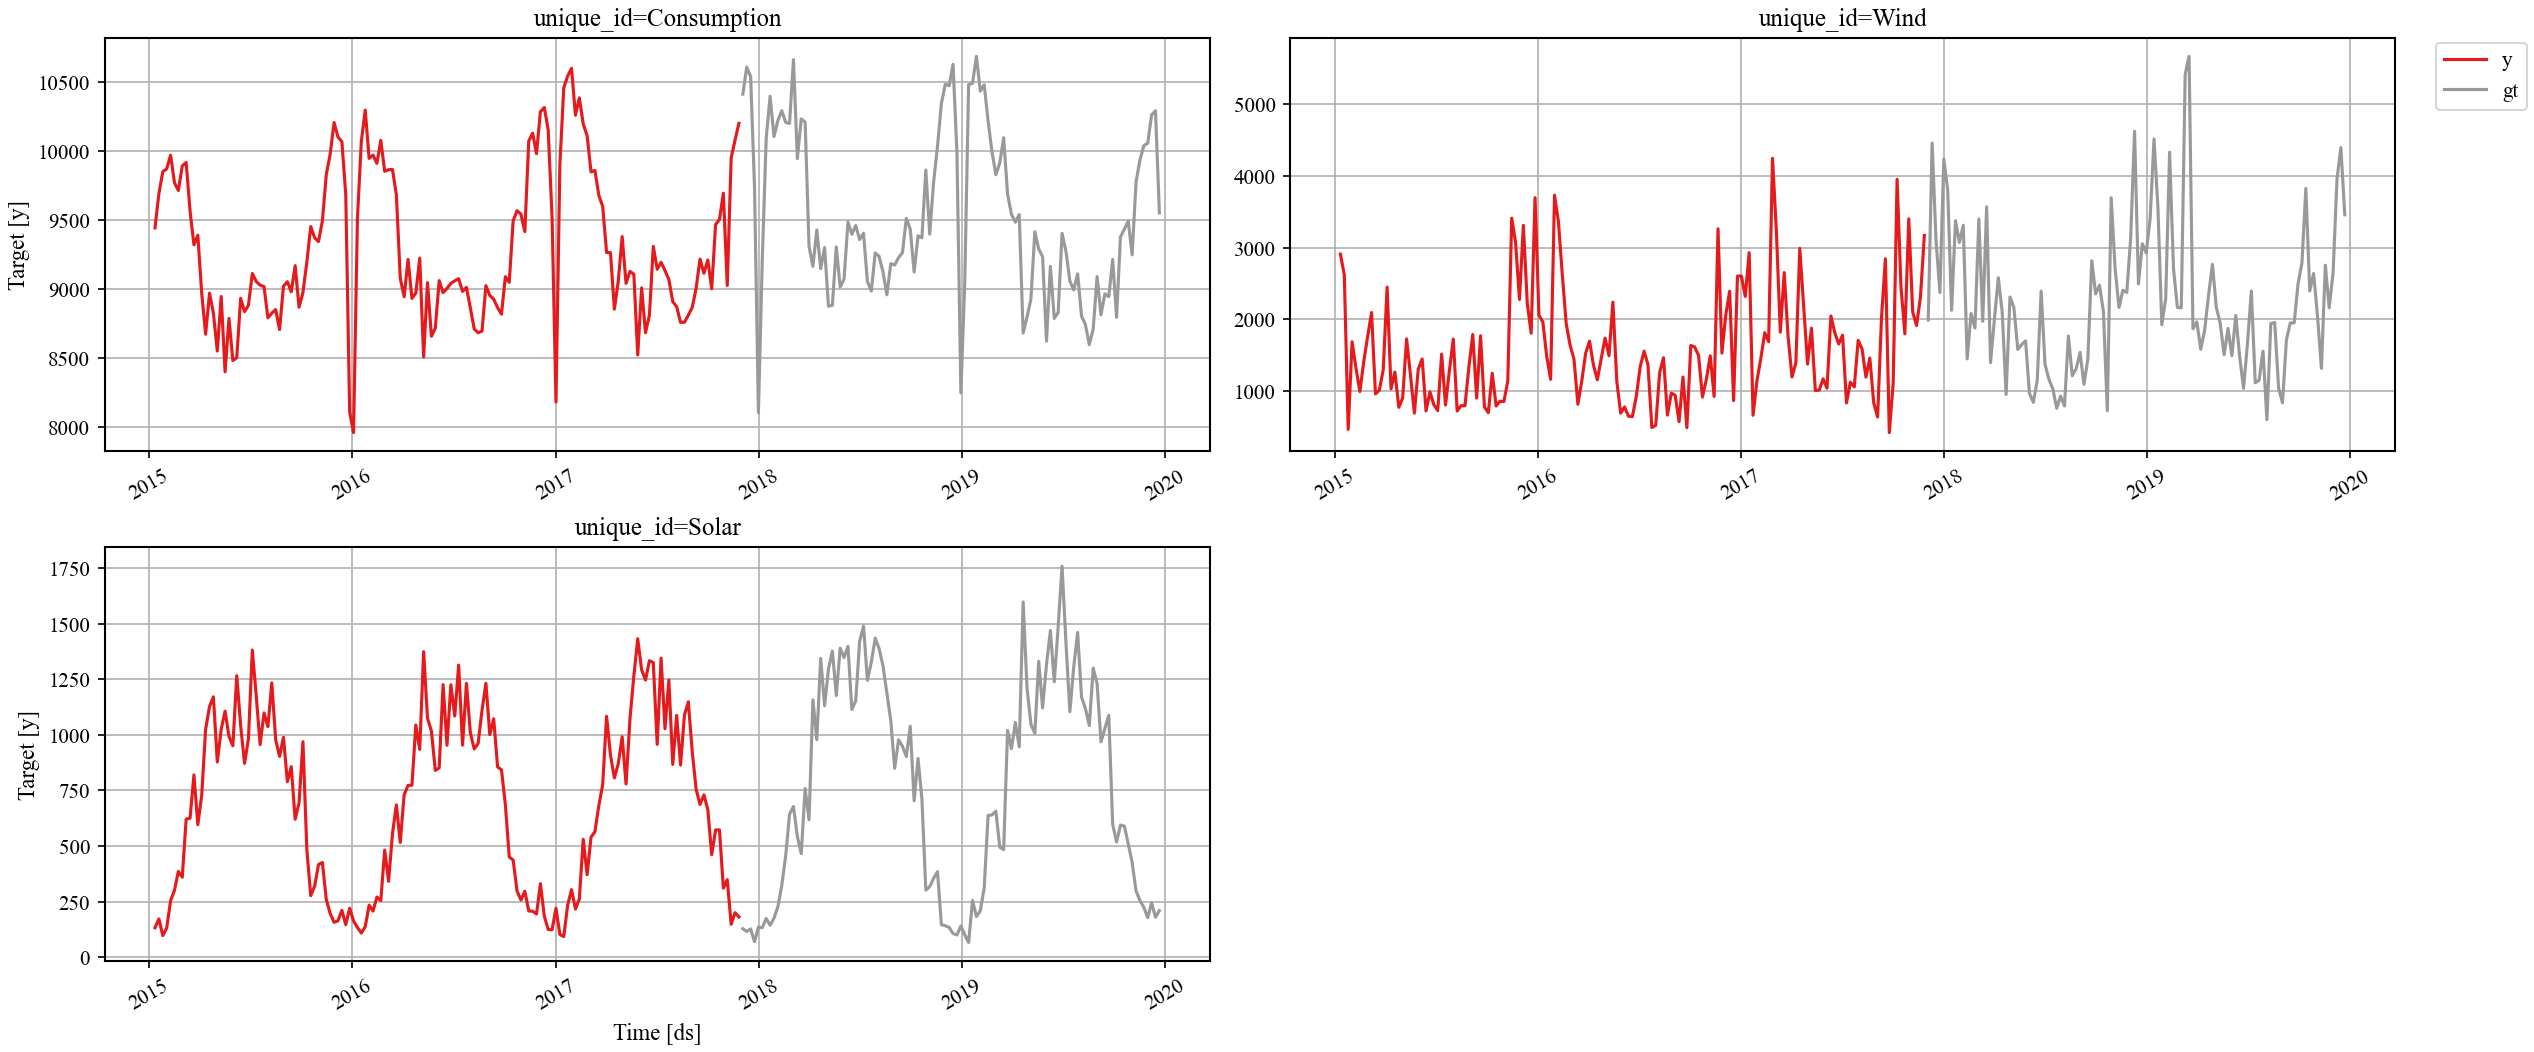

In [7]:
df= pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)
df.head(1)
ts = ['Consumption','Wind',	'Solar']
exog_cols = ['temperature','radiation_direct_horizontal']
y = df.resample('W').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]



ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

FREQ = y.index.freq


SEASON = 52

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

plot_series(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1')

In [14]:
season_mase = partial(mase, seasonality=SEASON)
metrics = [season_mase,  rmse, smape]

## Диагностика моделей временных рядов

### Методы диагностики моделей.
<!-- 1. Анализ метрик и сложности моделей
2. Анализ остатков моделей
3. Бектестинг и кросс-валидация моделей
4. Оценка интервального прогнозирования (разброс предсказания)
5. Анализ доверительности модели (надежность, устойчивость, интерпретируемость, конкретные ошибки и тд). -->

- __Анализ метрик и сложности моделей__ <br>
Оценка качества прогноза с помощью количественных метрик (MAE, RMSE, MAPE) на тестовой выборке, а также учёт сложности модели через информационные критерии (AIC, BIC). Это позволяет найти баланс между точностью и переобучением.
- __Анализ остатков моделей__ <br>
Проверка свойств in-sample остатков: отсутствие автокорреляции (тест Льюнга–Бокса), стационарность, приближённая нормальность и отсутствие систематических паттернов. Хорошая модель должна оставлять «белый шум».
- __Бектестинг и кросс-валидация моделей__ <br>
Моделирование реальных условий прогнозирования с помощью пошагового сдвига окна обучения (rolling-origin evaluation). Позволяет оценить устойчивость модели во времени и избежать оптимизма, связанного с однократным разбиением на train/test.
- __Оценка интервального прогнозирования (разброс предсказания)__ <br>
Анализ прогнозных интервалов: проверка покрытия (coverage — доля истинных значений внутри интервала) и sharpness (средняя ширина интервала). Надёжная модель даёт узкие интервалы с заданным уровнем покрытия (например, 90%).
- __Анализ доверительности модели__ <br>
Комплексная оценка надёжности: устойчивость коэффициентов при изменении данных, интерпретируемость результатов (соответствие предметной области), анализ типичных ошибок (например, занижение пиков или реакция на экстремальные события). Это помогает понять, можно ли доверять модели в реальных условиях.

### Оценка остатков модели.

#### Визуализация остатков 

Важным аспектом анализа любых моделей (в том числе и ARIMA и ETS, Prophet  и других) является [анализ остатков предсказания моделей](https://otexts.com/fpppy/nbs/05-toolbox.html#sec-diagnostics) (т.н. невязок или innovations - “innovation residuals”). Которые могут быть вычеслены как:
$$ e = y_t - \hat y_t$$


<blockquote>
    
- Остатки (__residuals__) — это общее понятие - разница между реальными наблюдениями и тем, что предсказала модель на обучающих данных.
- Инновации/невязка (__innovations__) — это то же самое, что остатки, но в контексте временных рядов: они показывают «новую информацию», которую модель не смогла предсказать на каждом шаге времени.
  
</blockquote>


В случае идеального прогноза остатки модели должны представлять собой белый шум. Это значит что такие остатки не объяснимы. 

Расмотрим пример простого алгоритма и его остатков.

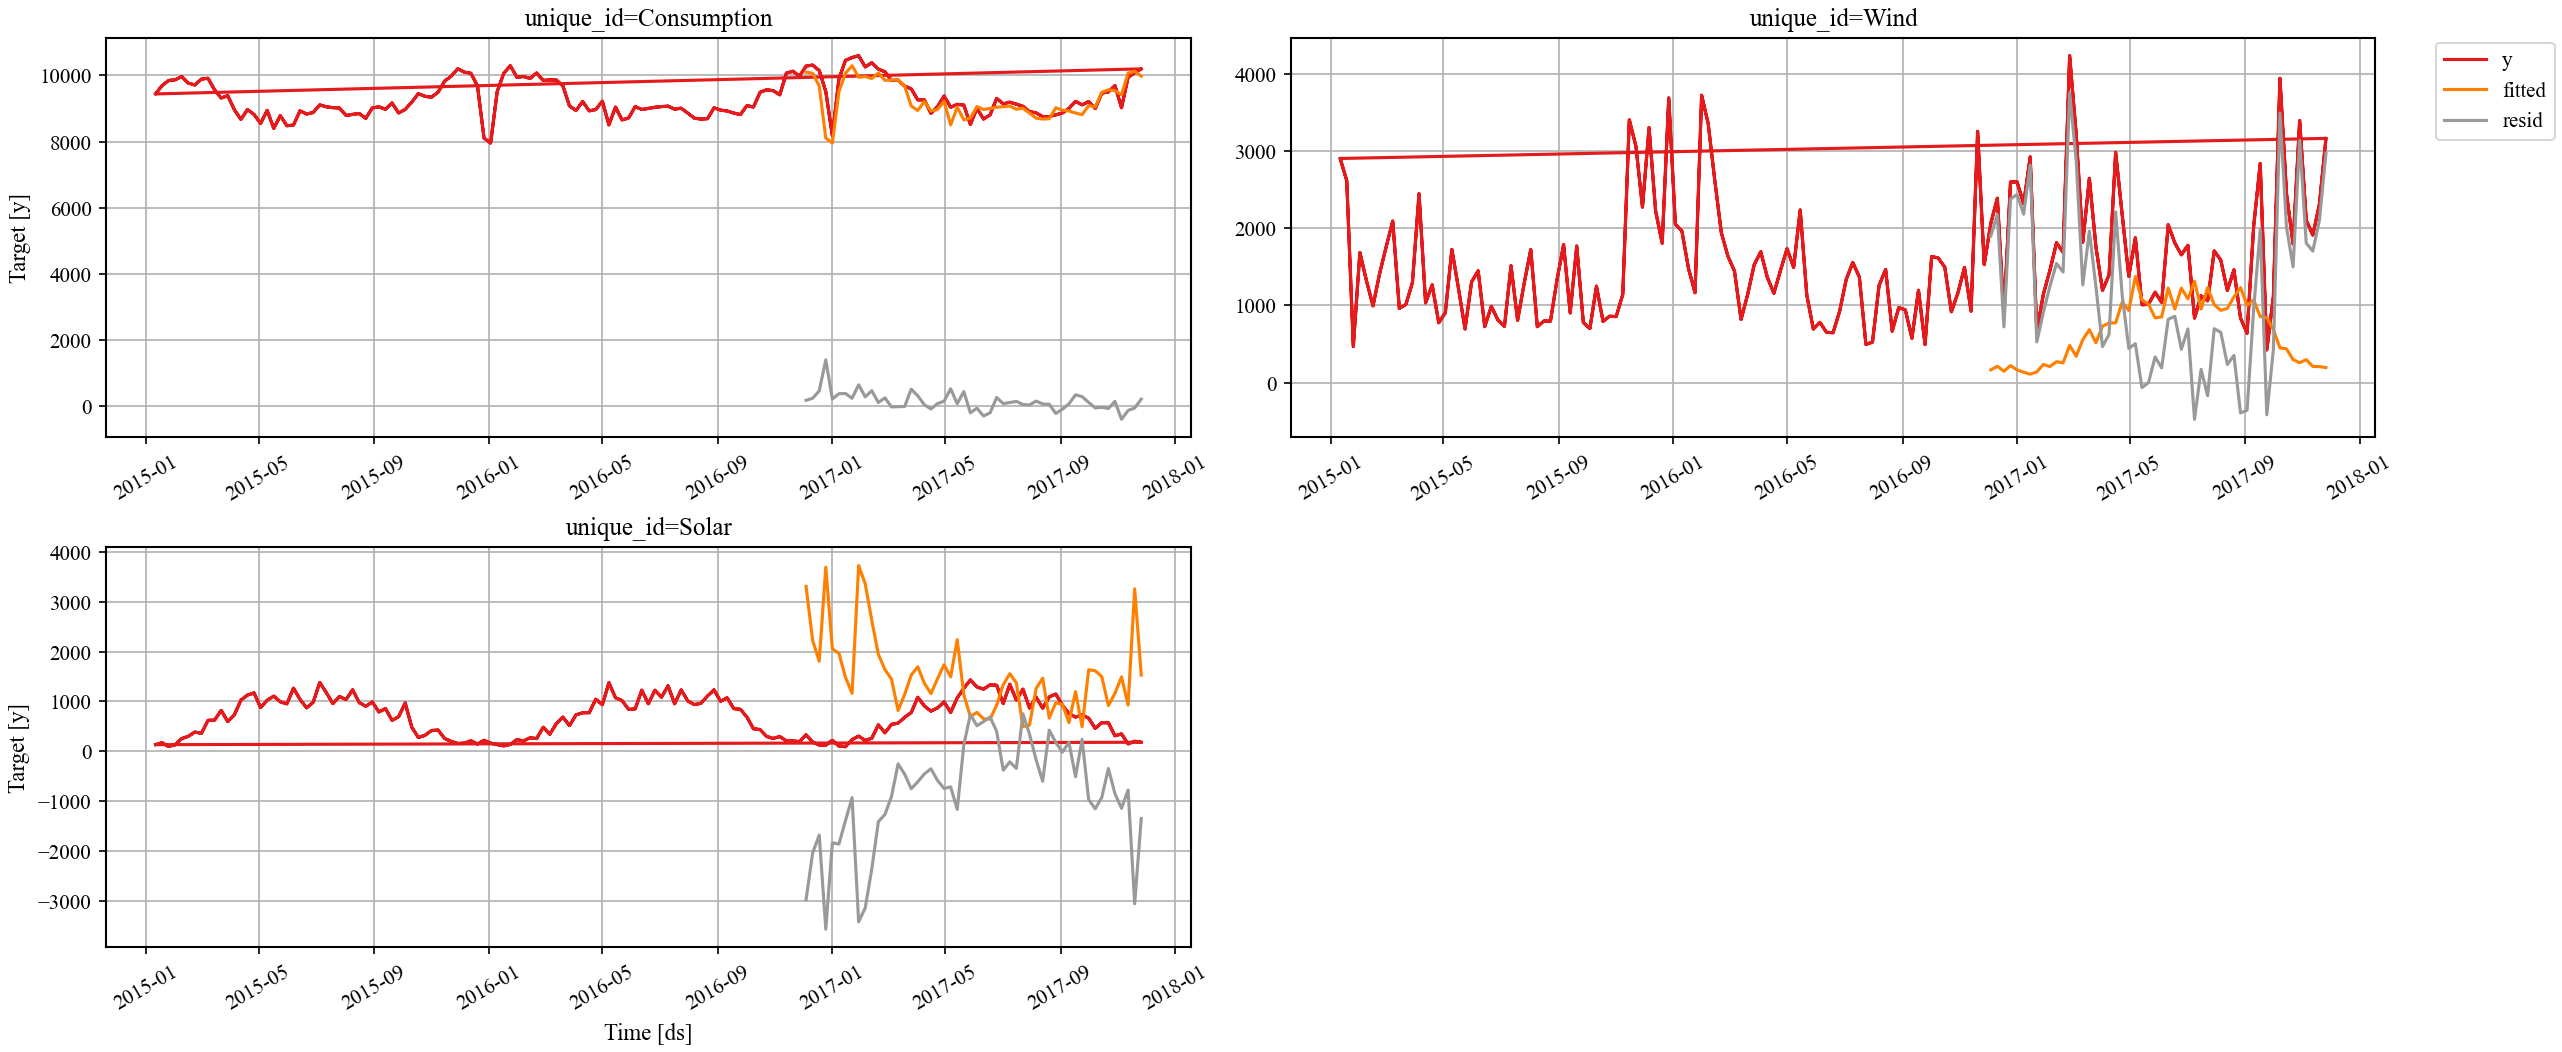

In [9]:
mean_method = SeasonalExponentialSmoothingOptimized(SEASON)
sf = StatsForecast(models=[mean_method], freq=FREQ)
sf.forecast(h=FH, df=df_train, fitted=True)
fitted_values = sf.forecast_fitted_values()
df_resid = df_train.copy()
df_resid["fitted"] = fitted_values["SeasESOpt"].values
df_resid["resid"] = df_resid["y"] - df_resid["fitted"]
plot_series(df_train, df_resid, palette='Set1')

Видно, что каждой модели остаток значительно отличается от белого шума. Это означает, что остаток информативен (содержит информацию, не описанную моделью).


#### Диагностика остатков

На самом деле диагонстика остатков часто строится [по известному алгоритму](https://otexts.com/fpppy/nbs/05-toolbox.html#example-forecasting-google-daily-closing-stock-prices).

Для каждого ВР построим
1. __Остатки во времени__ (график в левом верхнем углу).
   - График показывает наличие тренда и сезонности в остатках, а также гетеросекдостичность разброса (шумов).
2. __ACF__ (автокорреляционная функция) — график в правом верхнем углу.
   - Тут проверяется соотвествие остатков белому шуму и стационарность остатков. В иделае ACF должна иметь только нулевой лаг выше доверительного интервала.
   - В название графика  ACF также указается значение __теста  Льюнга–Бокса__. Если p-value теста Льюнга–Бокса > 0.05 (указано в заголовке) → автокорреляции нет (белый шум).
3. __Гистограмма остатков__ — график в левом нижнем углу.
   - Тут рассматривается на сколько гистограмма похоже на нормальное распределение, есть ли выбросы и тд.
   - Если есть сильный перекос → модель систематически завышает или занижает.
   - Если есть тяжелые хвосты - много выбросов.
   - Если распределение сильно отличается от нормального - модель неадекватна.
   - В заголовке указано значение Breusch–Pagan теста p-value.
   - Если BP p-value< 0.05 Отвергаем H₀ → гетероскедастичность присутствует.
4. __Q-Q plot__ (квантиль-квантильный график) — график в правом нижнем углу
   - График показывает сравнение модели и нормального распределения. Известны Q-Q plot для некоторых типичных видов распределний.
   - Например, точки изгибаются вверх/вниз → тяжёлые хвосты или перекос.
   - В название указано  p-value теста Jarque–Bera. Если p-value > 0.05 нормальность не отвергается (p-value < 0.05 → остатки не нормальны).

__Примеры выводов__:
- Если все 4 графика «хорошие» - модель адекватна, остатки похожи на белый шум.
- Если ACF чистый, но остальное плохо - модель динамику ловит, но, например, плохо калибрована.
- Если ACF плохой - модель недообучена — нужно улучшать спецификацию (больше лагов, сезонность и т.д.).


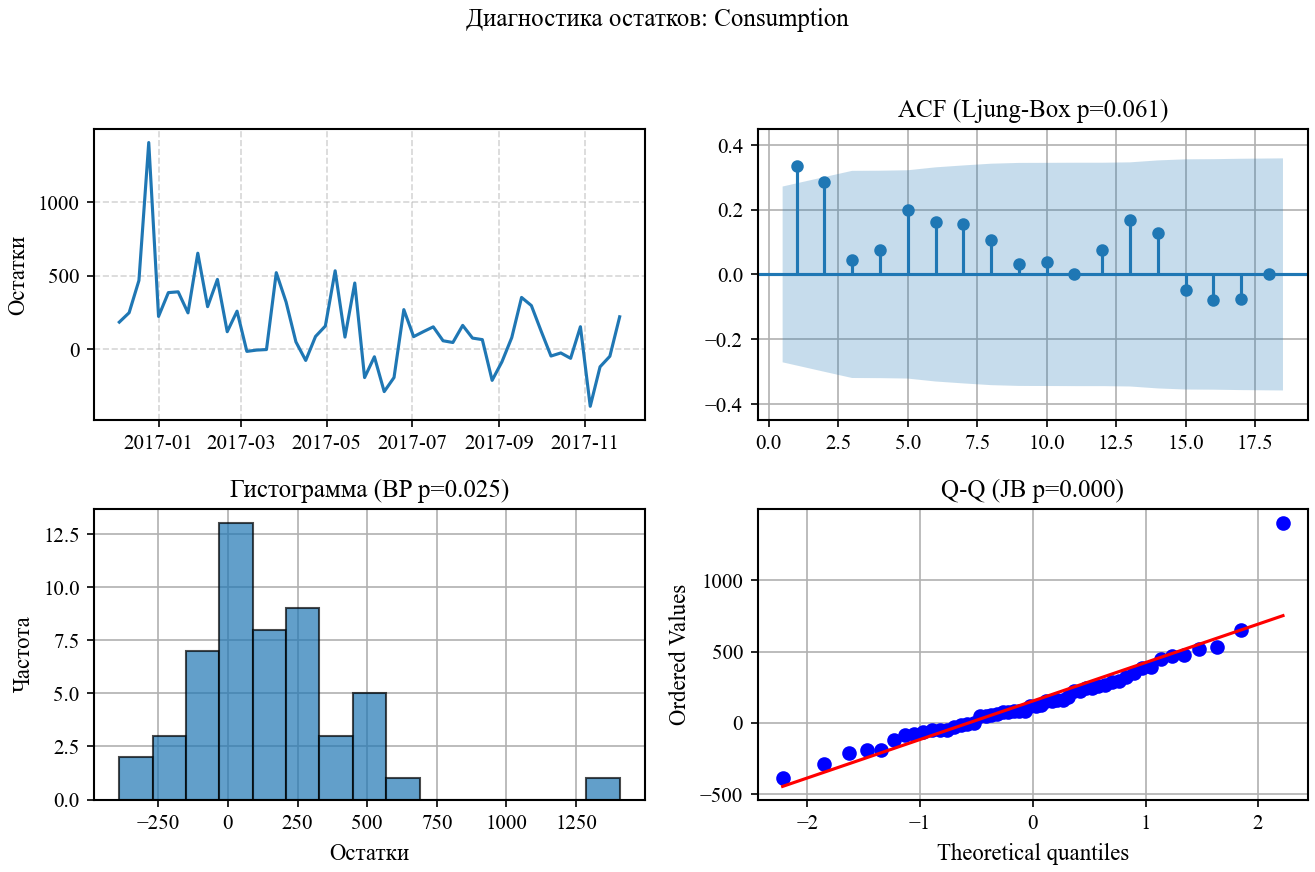

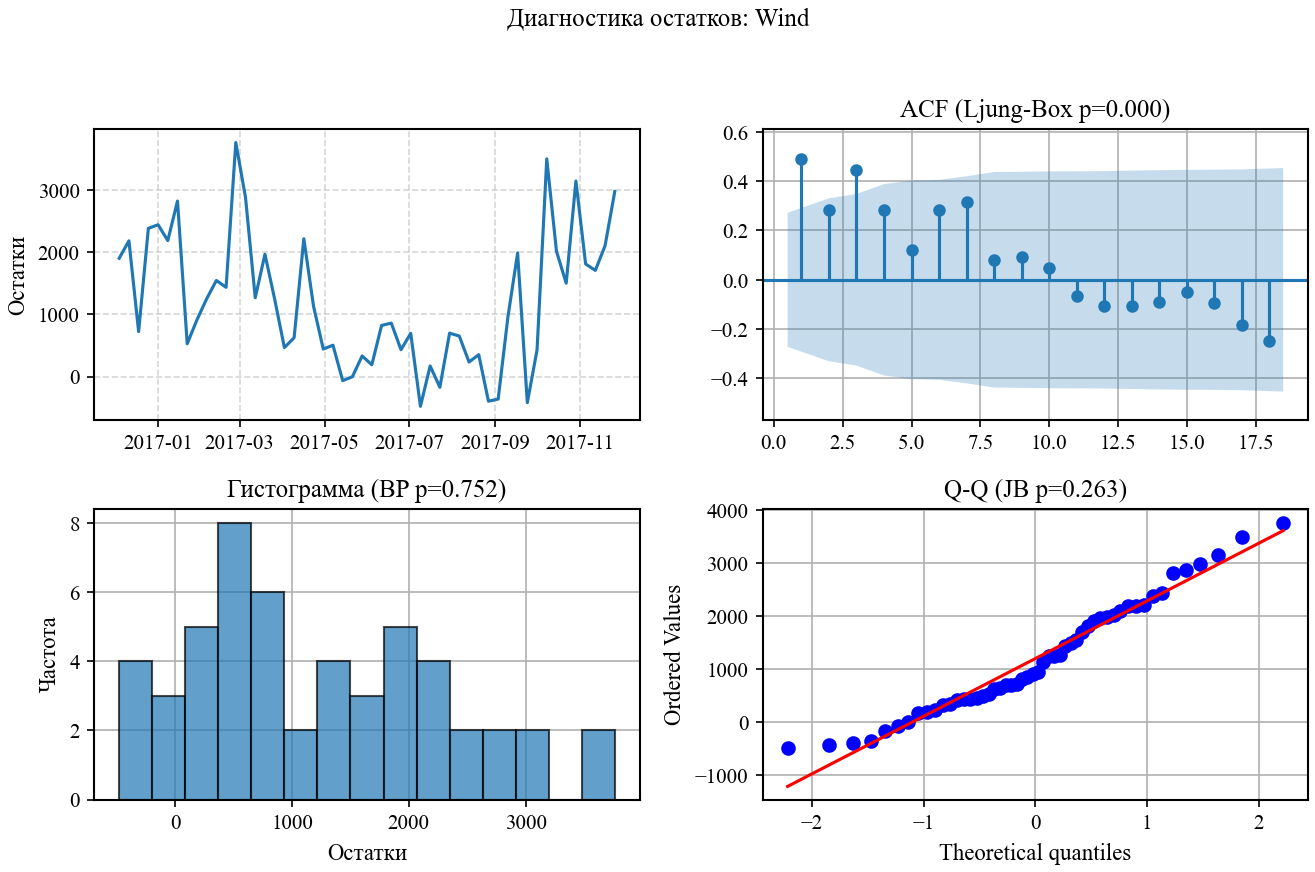

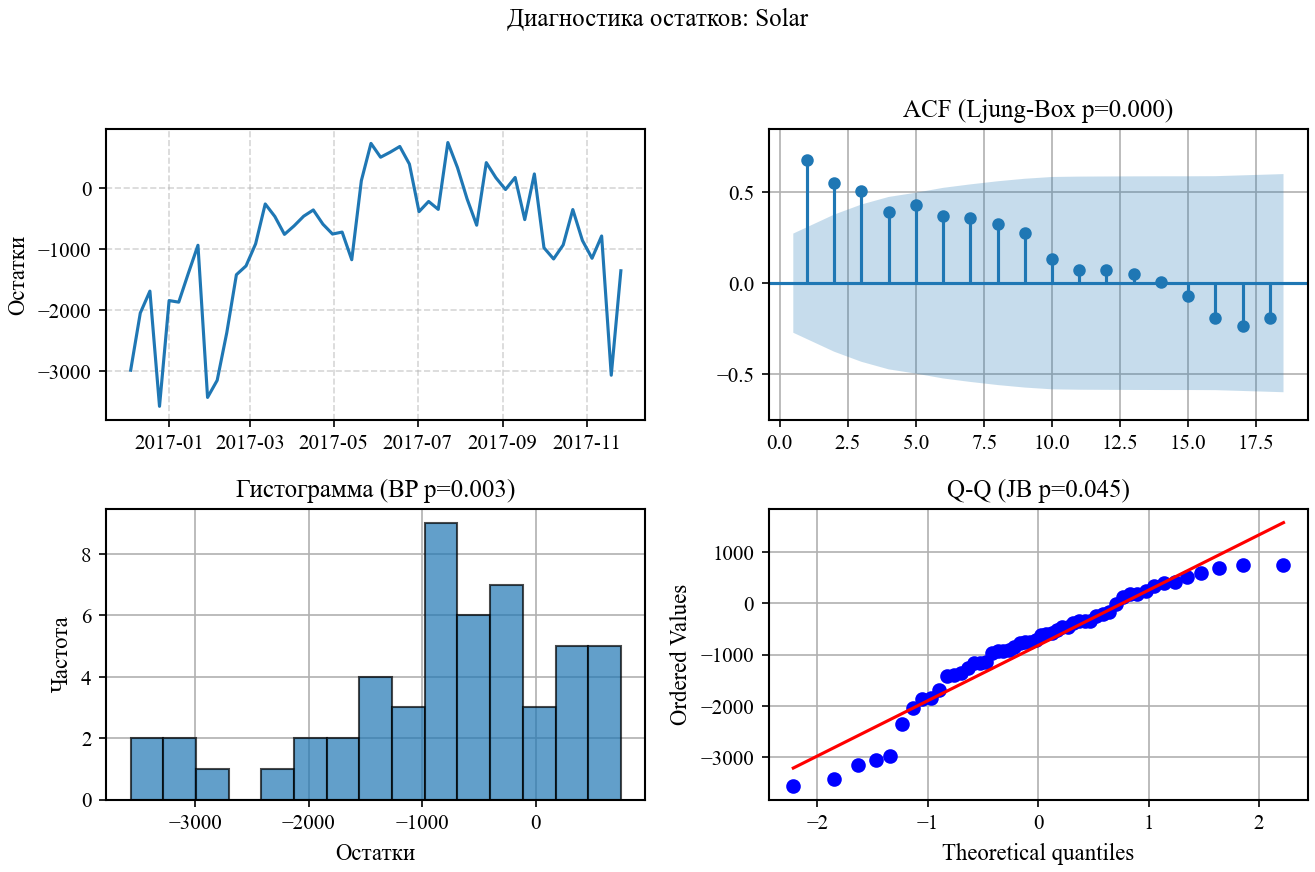

In [14]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.diagnostic import het_breuschpagan

from scipy import stats

for uid in df_resid['unique_id'].unique():
    subset = df_resid[df_resid['unique_id'] == uid]
    resid = subset['resid'].dropna()
    ds = subset.loc[subset['resid'].notna(), 'ds']
    
    if len(resid) < 10:
        continue
    
    # Тесты
    # lb_pval = acorr_ljungbox(resid, lags=min(10, len(resid)//2), return_df=True)['lb_pvalue'].min()

    T = len(resid)
    if SEASON and SEASON > 1:
        lags = min(2 * SEASON, T // 5)
    else:
        lags = min(10, T // 5)
    lags = max(lags, 1)
    
    lb_results = acorr_ljungbox(resid, lags=lags, return_df=True)
    lb_pval = lb_results['lb_pvalue'].iloc[-1]  # <-- итоговый p-value для Q*(lags)

    jb_stat, jb_pval = stats.jarque_bera(resid)
    
    fig, axes = plt.subplots(2, 2, figsize=(9, 6))
    fig.suptitle(f'Диагностика остатков: {uid}', fontsize=12)

    # 1. Остатки во времени
    axes[0, 0].plot(subset['ds'], subset['resid'])
    axes[0, 0].set_ylabel('Остатки')
    axes[0, 0].grid(True, linestyle='--', alpha=0.5)

    # 2. ACF
    plot_acf(resid, ax=axes[0, 1], zero=False, auto_ylims=True)
    axes[0, 1].set_title(f'ACF (Ljung-Box p={lb_pval:.3f})')

    # 3. Гистограмма
    axes[1, 0].hist(resid, bins=15, edgecolor='k', alpha=0.7)
    axes[1, 0].set_xlabel('Остатки')
    axes[1, 0].set_ylabel('Частота')

    exog = sm.add_constant(range(len(resid)))
    bp_stat, bp_pval, _, _ = het_breuschpagan(resid, exog)
    axes[1, 0].set_title(f"Гистограмма (BP p={bp_pval:.3f})")
    
    # 4. Q-Q plot
    stats.probplot(resid, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title(f'Q-Q (JB p={jb_pval:.3f})')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

#### Упражнение
1. Провести оценку для базовых моделей ARIMA, Prophet, ETS, сравните модели и выберите лучшую 

## Оценека неопределенности модели
### Обратное и последовательное тестирование моделей

Существует как минимум четыре [источника неопределенности](https://nixtlaverse.nixtla.io/mlforecast/docs/tutorials/prediction_intervals_in_forecasting_models.html#importance-of-confidence-interval-prediction-in-time-series) при прогнозировании с помощью моделей временных рядов:
* Случайная составляющая ошибки (флуктуации);
* Ошибка оценки параметров (смещение);
* Ошибка связанная с выбором параметров модели на исторических данных (обобщающая способность, переобучение);
* Ошибка связанная с продолжением процесса генерирования исторических данных в будущем (воспроизводимость паттерном поведения ВР, дрифт данных).

<!-- - __Случайная составляющая ошибки (флуктуации)__ — это неустранимый шум, присущий самой природе данных. Даже при идеально подобранной модели будущие наблюдения будут отклоняться от прогноза из-за непредсказуемых внешних воздействий или внутренней стохастичности процесса.
- __Ошибка оценки параметров (смещение)__ — возникает потому, что параметры модели (например, коэффициенты регрессии или веса в дереве решений) оцениваются на конечной выборке. Эти оценки подвержены выборочной изменчивости: при другом наборе исторических данных они были бы иными, что привело бы к иному прогнозу.
- __Ошибка, связанная с выбором модели на исторических данных__ — отражает неопределённость в архитектуре или гиперпараметрах модели. Мы выбираем одну модель из множества возможных (ARIMA, XGBoost, Prophet и т.д.), но не знаем, действительно ли она наилучшим образом описывает истинный процесс. Эта неопределённость включает риски переобучения, недообучения и ограниченную обобщающую способность.
- __Ошибка, связанная с продолжением процесса генерирования данных в будущем (дрифт данных)__ — предполагает, что закономерности, наблюдаемые в прошлом, сохранятся в будущем. Однако в реальности могут произойти структурные изменения: смена режима работы системы, внешние шоки (экономические, климатические, технологические), изменение поведения пользователей. В таких случаях даже идеальная модель на исторических данных даёт смещённый прогноз. -->

Самый простой способ  повышения надежности  оценки производительности - мы можем  разделить  набор данных несколько раз по аналогии с методом `k-folds`. Однако, в соответствии с особенностями временных рядов - временной связанностью метод`k-folds` должен [не нарушать принцип казуальности](https://forecastegy.com/posts/time-series-cross-validation-python/). Другими словами [выборка валидации должна следовать за тренировочными данными](https://otexts.com/fpp3/tscv.html). Проще всего организовать такое следование в рамках имеющейся тренировочной выборки. Другими словами модель испытывается на исторических (ретро) данных. __Такой подход также известен как [<tt>backtesting/ walk-forward validation</tt>](https://joaquinamatrodrigo.github.io/skforecast/0.8.1/user_guides/backtesting.html)__.

>Напомним, результат [кросс-валидации](https://www.statology.org/k-fold-cross-validation/) по нескольким блокам более валиден [(менее смещен)](https://machinelearningmastery.com/k-fold-cross-validation/), нежели валидация одной [отложенной выборкой](https://scikit-learn.org/stable/modules/cross_validation.html).

>Backtesting (ретроспективное тестирование) и walk-forward validation  (пошаговая валидация) часто используются как синонимы, но в строгом смысле они отражают разные варианты  одного и того же принципа.
>
>__Walk-forward validation__ -  процедура при которой: начальное обучающее окно фиксируется (например, первые 365 дней),
модель тестируется на следующем коротком интервале (например, 7 дней), затем обучающее окно расширяется (или сдвигается), включая данные, использованные для теста, процесс повторяется до конца выборки.
>
>__Backtesting__ не имеет конкретного алгоритма , но часто преполагает проверку точности модели на последовательности интервалов без дообучения - то есть имитация работы модели в реальной среде



### Walk-forward validation

#### ExpandingWindowSplitter

В случае временного ряда кросс валидация может быть выполнена в скользящем окне по данным  [<tt>rolling backtest evaluation</tt>](https://docs.aws.amazon.com/whitepapers/latest/time-series-forecasting-principles-with-amazon-forecast/step-4-evaluate-predictors.html#prediction-quantiles-and-accuracy-metrics).
> [Приемущественно метода](https://mydata.ch/backtesting-in-time-series-forecasting-for-maximum-performance/)  бектеста скользящим окном следующие:
>* позволяет  быть уверенным, что  прогнозы точны и последовательны в течение длительного периода времени.
>* может помочь  найти и исправить "плавоющие" ошибки в модели данных. То есть редкие, но достаточно регулярные ошибки (неучтенную информоацию), которые можно участь в модели.
>* может помочь выявить недостающие внешние факторы в данных, которые помогут модели делать более точные прогнозы.
<!-- ✅It allows you to ensure that your forecasts are accurate and consistent over a long period of time

✅It can help you to find and correct errors in your models.

✅It can help you to identify missing external factors in your data that would help the model make better forecasts -->

>Напомним, что в прогнозировании временных рядов под <tt>бэктестингом</tt> понимается процесс проверки модели прогноза на исторических данных. Этот метод предполагает пошаговое движение назад во времени, чтобы оценить, насколько хорошо показала бы себя модель, если бы она использовалась для прогнозирования в этот период времени.

С технической точки зрения идея тут [заключается следующем](https://joaquinamatrodrigo.github.io/skforecast/0.11.0/user_guides/backtesting.html). Задается некторая ширина окна временного ряда. Заданное окно скользит по временному ряду с начального положения, например, таким образом, что все данные перед ним являются тренировочными, а после тестовыми. Могут быть и [другие стратегии](https://www.sktime.net/en/stable/examples/forecasting/window_splitters.html), например, что только лишь выборка заданного размера перед окном является тренировочной. Такие стратегии называются `ExpandingWindowSplitter` и `SlidingWindowSplitter` соответственно.

Для использования данных стратегий рекомендуем задавать оконо списком чисел вместо дат. Попробуем для начала визуализировать `ExpandingWindowSplitter`

> Отметим что по своей идеалогии данная процедура аналогична тому, что модель бы тестировалась на поступающих данных в соответствующих рабочих режмах. При этом целью такого тестирования бы была оценка работоспособности модели. Другими словами тестирование гипотезы о необходимости сменить модель (например переобучить). Такая процедура называется [<tt>walk-forward validation</tt>](https://machinelearningmastery.com/backtest-machine-learning-models-time-series-forecasting/).

<!-- In time series forecasting, backtesting refers to the process of validating a predictive model using historical data. The technique involves moving backwards in time, step-by-step, to assess how well a model would have performed if it had been used to make predictions during that time period. -->

In [12]:
forecaster = SARIMAX(order=(3, 1, 1), seasonal_order=(0, 1, 0, 52))
forecaster.fit(y_train)
print(forecaster.summary())

                                      SARIMAX Results                                      
Dep. Variable:                         Consumption   No. Observations:                  170
Model:             SARIMAX(3, 1, 1)x(0, 1, [], 52)   Log Likelihood                -680.375
Date:                             Tue, 16 Apr 2024   AIC                           1372.750
Time:                                     14:26:27   BIC                           1389.323
Sample:                                 01-01-2015   HQIC                          1379.479
                                      - 03-29-2018                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0781      0.289     -0.270      0.787      -0.645       0.488
ar.L1         -0.1244      

В полученных в `summary` результатах можно сделать [следующие выводы](https://jadsmkbdatalab.nl/forecasting-with-sarimax-models/): 
+ $Prob(Q) > 0.05$ ->  Мы **не можем** отвергать нулевую гипотезу (о том, что остатки некоррелированы). То есть предполагаем, что **остатки не коррелированы**.
+ $Prob(JB) < 0.05$ -> Мы **отвергаем нулевую гипотезу** (о том, что остатки распределены нормально). Следовательно, **остатки не являются нормально распределенными**.  
+ $Prob(H) <0.05$ -> Мы **отвергаем нулевую гипотезу** (об отсутствии гетеросекдостичности). Следовательно **гетеросекдостичность присутствует в остатках** в какой то мере.
+ [Не все коэффициенты важны](https://www.machinelearningplus.com/time-series/arima-model-time-series-forecasting-python/) так как для них коэффициента `p-value` должно быть почти нулевое в графе $P>|z|$.

Помимо табличного представления, мы можем проводить [диагностику остатков](https://otexts.com/fpp3/residuals.html) графическим способом. Напомним, что остатки в данном контексте означают разность модели, аппроксимированной при помощи `SARIMA` и тренировочных данных.
Отметим, что данный способ не является стандартным методом класса `SARIMAX`, однако присутствует в нем.

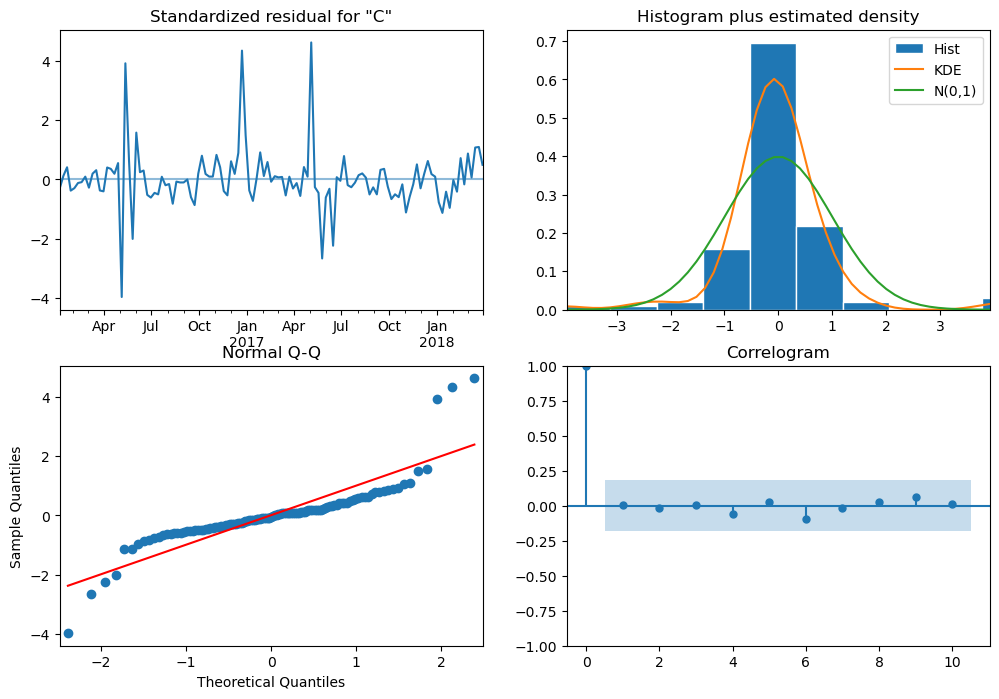

In [13]:
forecaster._fitted_forecaster.plot_diagnostics(figsize=(12,8));

<!-- from auto_ts import auto_timeseries
df = pd.DataFrame(y_train)
df["data"] = df.index.values
df.index = np.arange(len(df))
# df
#-----------------------------------
model = auto_timeseries(score_type='rmse',
                        time_interval='W',
                        non_seasonal_pdq=None, 
                        seasonality=False, 
                        seasonal_period=52,
                        model_type=['best'],
                        dask_xgboost_flag=False,
                        verbose=2)

model.fit(df, 'data','Consumption')
#-----------------------------------

df_test = pd.DataFrame(y_test)
df_test["data"] = df_test.index.values
df_test.index = np.arange(len(df_test))

predictions  = model.predict(df_test, model='best')
df_test['pred'] = predictions['yhat'].values
df_test.head()
#----------------------
y_pred = pd.DataFrame(df_test['pred'].values, index = y_test.index)

plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])

print(f'sMAPE = {smape(y_pred.values, y_test.values):.3f}') -->